In [1]:
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("../data/processed/customer_features.csv")
df.head()

,customer_id,recency_days,frequency,monetary,avg_order_value,total_interactions,last_interaction_days,interaction_types_count,engagement_segment,has_purchased,engaged_not_purchased,purchase_frequency_rate,interaction_purchase_ratio,customer_segment,location,acquisition_channel,age,gender
0,C00001,21,31,482863.71,15576.248710,335,7,4,High Engagement,1,0,0,10,medium,Bhubaneswar,ads,25,male
1,C00002,9,45,820236.81,18227.484667,389,4,4,High Engagement,1,0,0,8,high,Hyderabad,referral,47,female
2,C00003,550,0,0.00,0.000000,8,517,4,Medium Engagement,0,1,0,0,low,Ahmedabad,organic,46,female
3,C00004,10,31,537397.24,17335.394839,319,9,4,High Engagement,1,0,0,10,medium,Bangalore,organic,38,male
4,C00005,4,95,1556310.10,16382.211579,752,0,4,High Engagement,1,0,0,7,high,Hyderabad,referral,37,female


In [3]:
df.shape

(8000, 18)

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8000 entries, 0 to 7999
Data columns (total 18 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   customer_id                 8000 non-null   object 
 1   recency_days                8000 non-null   int64  
 2   frequency                   8000 non-null   int64  
 3   monetary                    8000 non-null   float64
 4   avg_order_value             8000 non-null   float64
 5   total_interactions          8000 non-null   int64  
 6   last_interaction_days       8000 non-null   int64  
 7   interaction_types_count     8000 non-null   int64  
 8   engagement_segment          8000 non-null   object 
 9   has_purchased               8000 non-null   int64  
 10  engaged_not_purchased       8000 non-null   int64  
 11  purchase_frequency_rate     8000 non-null   int64  
 12  interaction_purchase_ratio  8000 non-null   int64  
 13  customer_segment            8000 

In [5]:
df.describe()

,recency_days,frequency,monetary,avg_order_value,total_interactions,last_interaction_days,interaction_types_count,has_purchased,engaged_not_purchased,purchase_frequency_rate,interaction_purchase_ratio,age
count,8000.000000,8000.000000,8.000000e+03,8000.000000,8000.000000,8000.000000,8000.000000,8000.000000,8000.000000,8000.0,8000.000000,8000.000000
mean,405.649625,3.053875,5.460080e+04,2207.274430,31.250000,401.051125,0.569750,0.125250,0.024375,0.0,1.576250,34.522000
std,239.550748,11.690576,2.151391e+05,6823.790323,106.227837,243.356694,1.373361,0.331023,0.154220,0.0,4.985182,9.499266
min,0.000000,0.000000,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,18.000000
25%,205.750000,0.000000,0.000000e+00,0.000000,0.000000,203.000000,0.000000,0.000000,0.000000,0.0,0.000000,27.000000
50%,405.000000,0.000000,0.000000e+00,0.000000,0.000000,402.000000,0.000000,0.000000,0.000000,0.0,0.000000,34.000000
75%,614.000000,0.000000,0.000000e+00,0.000000,0.000000,612.000000,0.000000,0.000000,0.000000,0.0,0.000000,41.000000
max,820.000000,124.000000,2.812845e+06,141831.360000,838.000000,820.000000,4.000000,1.000000,1.000000,0.0,83.000000,65.000000


## Step 1: Distribution Analysis (Recency & Interaction)

We analyze:
- `recency_days` → purchase inactivity
- `last_interaction_days` → engagement inactivity

Goal:
- Understand distribution
- Identify potential churn thresholds

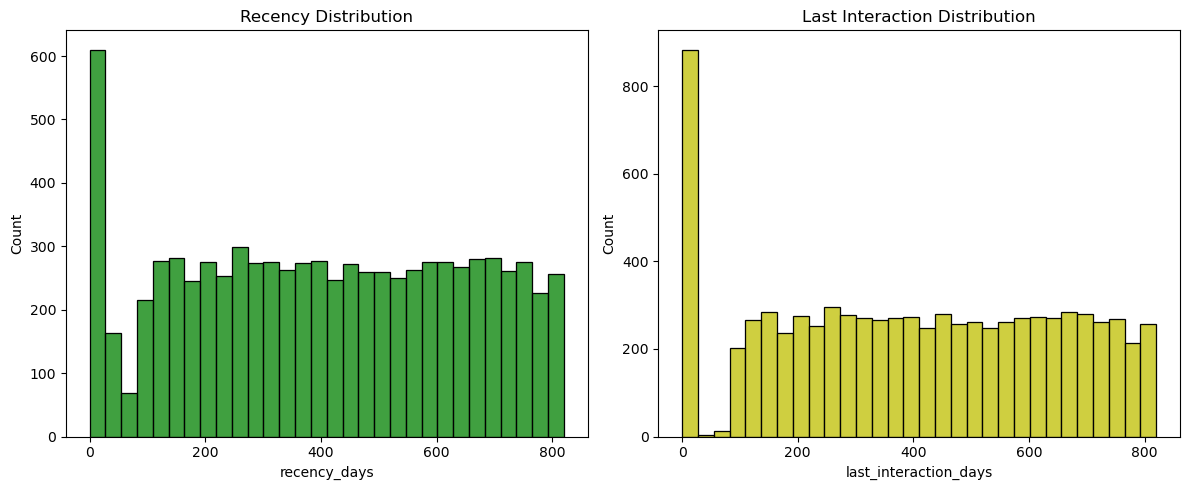

In [6]:
# Create figure
fig, ax = plt.subplots(1, 2, figsize=(12, 5))

# Recency distribution
sns.histplot(df["recency_days"], bins=30, ax=ax[0], color="g")
ax[0].set_title("Recency Distribution")

# Interaction recency distribution
sns.histplot(df["last_interaction_days"], bins=30, ax=ax[1], color="y")
ax[1].set_title("Last Interaction Distribution")

plt.tight_layout()
plt.show()

## Step 2: Percentile Analysis

Since distributions are flat (no natural cutoff), we use percentiles to define inactivity thresholds.

In [7]:
# Percentiles for recency
recency_percentiles = df["recency_days"].quantile([0.5, 0.7, 0.8, 0.9])
interaction_percentiles = df["last_interaction_days"].quantile([0.5, 0.7, 0.8, 0.9])

print("Recency Percentiles:\n", recency_percentiles)
print("Interaction Percentiles:\n", interaction_percentiles)

Recency Percentiles:
 0.5    405.0
0.7    573.3
0.8    653.2
0.9    734.0
Name: recency_days, dtype: float64
Interaction Percentiles:
 0.5    402.0
0.7    570.0
0.8    651.0
0.9    732.0
Name: last_interaction_days, dtype: float64


## Step 3: Define Churn

Churn is defined using recency:

- Customers with `recency_days` > 80th percentile are considered churned

Reason:
- No natural cutoff in data
- Percentile-based approach ensures balanced segmentation
- Recency captures purchase inactivity effectively

In [8]:
# Define threshold
threshold = df["recency_days"].quantile(0.8)

# Create churn column
df["churn"] = (df["recency_days"] > threshold).astype(int)

# Check distribution
df["churn"].value_counts(normalize=True)

churn
0    0.8
1    0.2
Name: proportion, dtype: float64

## Step 4: Prevent Data Leakage

We drop the following features:

- `recency_days`
- `last_interaction_days`

But Why?
- Churn was defined using `recency_days` (time since last purchase)
- Including it as a feature would cause data leakage
- `last_interaction_days` is highly correlated with `recency_days`, creating indirect leakage

By removing these features, the model will learn real behavioral patterns instead of relying on time-based shortcuts.

In [15]:
# Drop leakage-prone features
df = df.drop(columns=["recency_days", "last_interaction_days"])

# Quick check
df.columns

Index(['customer_id', 'frequency', 'monetary', 'avg_order_value',
       'total_interactions', 'interaction_types_count', 'engagement_segment',
       'has_purchased', 'engaged_not_purchased', 'purchase_frequency_rate',
       'interaction_purchase_ratio', 'customer_segment', 'location',
       'acquisition_channel', 'age', 'gender', 'churn'],
      dtype='object')

## Step 5: Churn vs Engagement

We analyze how churn varies across engagement segments.

Goal:
- Understand if low engagement leads to higher churn
- Validate behavioral assumptions

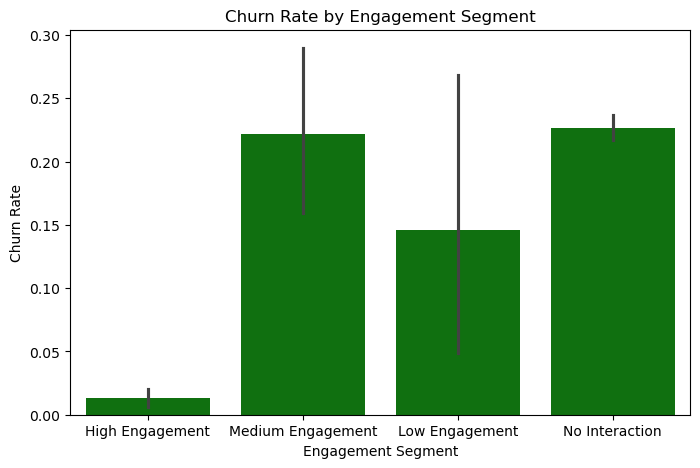

In [16]:
plt.figure(figsize=(8, 5))

sns.barplot(
    x="engagement_segment",
    y="churn",
    data=df,
    color="g"
)

plt.title("Churn Rate by Engagement Segment")
plt.ylabel("Churn Rate")
plt.xlabel("Engagement Segment")

plt.show()

## Step 6: Churn vs Purchase Behavior

We analyze how churn relates to:
- frequency
- monetary value

Goal:
- Understand if low-value customers churn more
- Identify high-value at-risk users

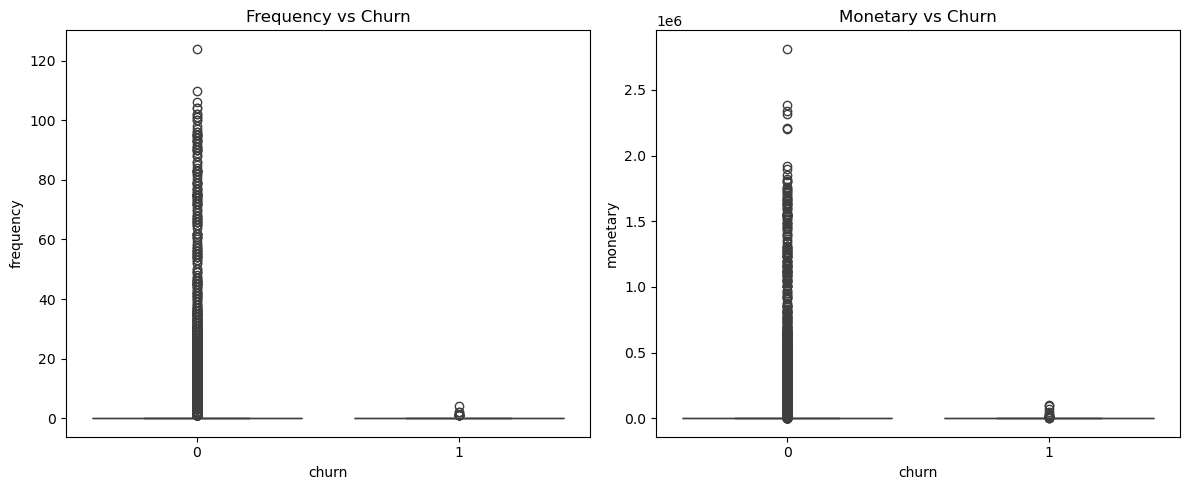

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Frequency vs churn
sns.boxplot(x="churn", y="frequency", data=df, ax=axes[0])
axes[0].set_title("Frequency vs Churn")

# Monetary vs churn
sns.boxplot(x="churn", y="monetary", data=df, ax=axes[1])
axes[1].set_title("Monetary vs Churn")

plt.tight_layout()
plt.show()

## Step 7: Engaged but Not Purchased

We analyze users who interact but do not convert.

Goal:
- Identify potential customers
- Understand conversion gaps

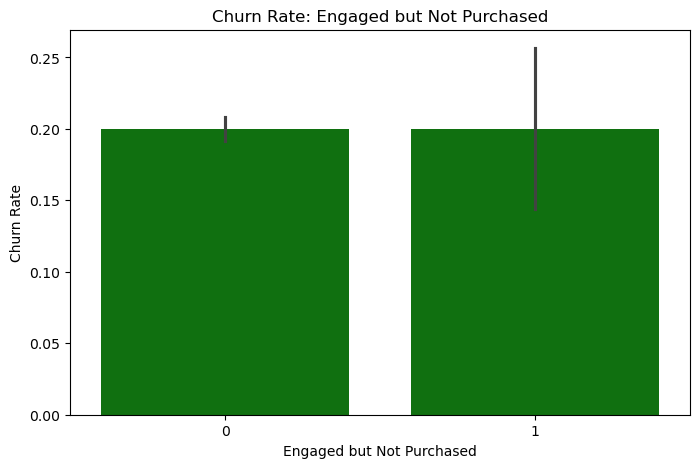

In [18]:
plt.figure(figsize=(8, 5))

sns.barplot(
    x="engaged_not_purchased",
    y="churn",
    data=df,
    color="g"
)

plt.title("Churn Rate: Engaged but Not Purchased")
plt.xlabel("Engaged but Not Purchased")
plt.ylabel("Churn Rate")

plt.show()

## Step 8: Interaction vs Purchase Efficiency

We analyze `interaction_purchase_ratio`.

Goal:
- Understand how efficiently users convert interactions into purchases
- Check if low efficiency leads to churn

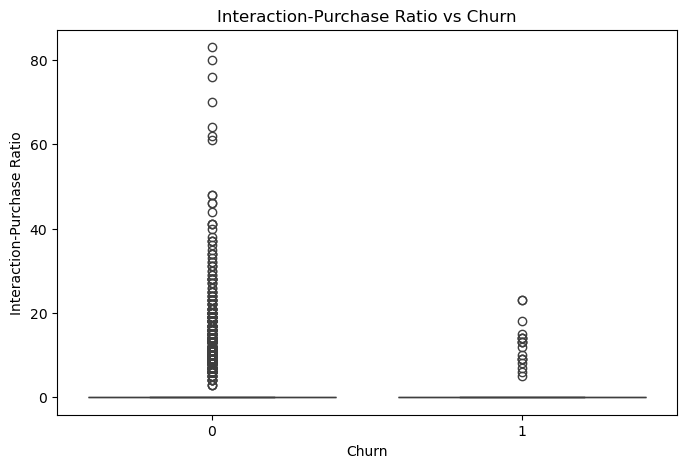

In [19]:
plt.figure(figsize=(8, 5))

sns.boxplot(x="churn", y="interaction_purchase_ratio", data=df)

plt.title("Interaction-Purchase Ratio vs Churn")
plt.xlabel("Churn")
plt.ylabel("Interaction-Purchase Ratio")

plt.show()

## Step 9: Churn by Customer Segment

We analyze churn across predefined customer segments.

Goal:
- Understand which segments are most at risk
- Identify high-value customers who might churn

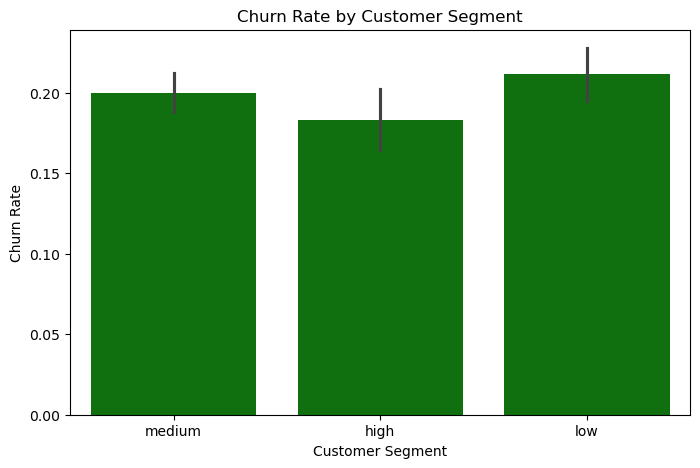

In [20]:
plt.figure(figsize=(8, 5))

sns.barplot(
    x="customer_segment",
    y="churn",
    data=df,
    color="g"
)

plt.title("Churn Rate by Customer Segment")
plt.xlabel("Customer Segment")
plt.ylabel("Churn Rate")

plt.show()

## Key Insights from EDA

1. Churn Definition
- Defined using recency (80th percentile threshold)
- Resulted in ~20% churn rate

2. Engagement Behavior
- High engagement users have very low churn
- Medium engagement users show highest churn (instability phase)
- Low engagement users are partially recoverable

3. Purchase Behavior
- Low frequency and low monetary strongly associated with churn
- High-value users rarely churn
- Churn occurs before habit formation

4. Interaction Efficiency
- Low interaction-to-purchase ratio linked to churn
- High interaction users are highly retained
- Engagement itself drives retention

5. Engaged but Not Purchased
- Not a strong churn predictor
- Represents conversion opportunity

6. Customer Segments
- Similar churn rates across segments
- Behavior is a stronger predictor than segment labels

## Overall Conclusion

Churn is primarily driven by lack of engagement and failure to convert early interactions into consistent usage.

The problem is more about user activation than long-term retention.